https://habr.com/ru/articles/821547/#clustering_metrics

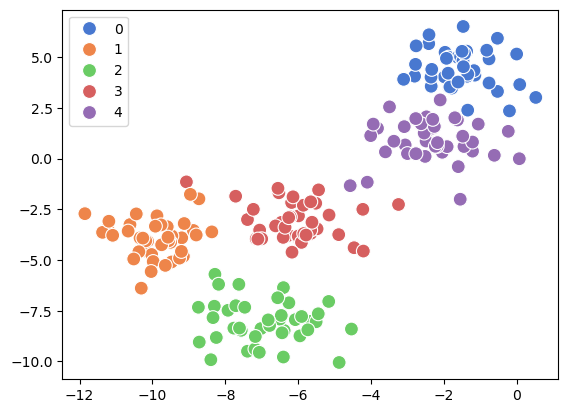

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AffinityPropagation
import warnings; warnings.filterwarnings('ignore')
X, y = make_blobs(n_samples=200, n_features=2, centers=5, random_state=1)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='muted', s=100);

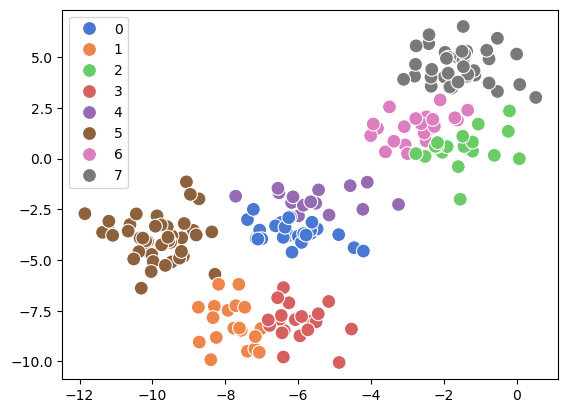

In [5]:
ap = AffinityPropagation()
y_AP = ap.fit_predict(X)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_pred, palette='muted', s=100);

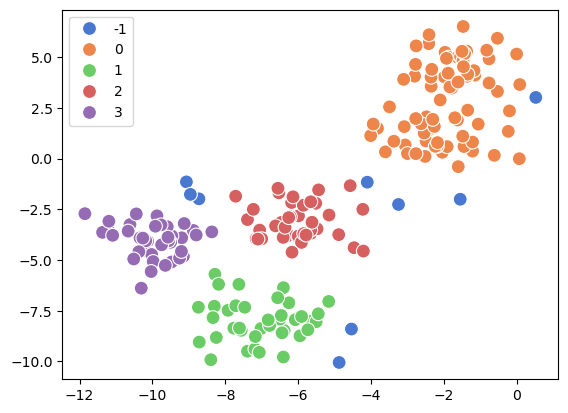

In [3]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_prep = ss.fit_transform(X)
dbscan = DBSCAN(eps=0.3)
y_pred2 = dbscan.fit_predict(X_prep)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_pred2, palette='muted', s=100);

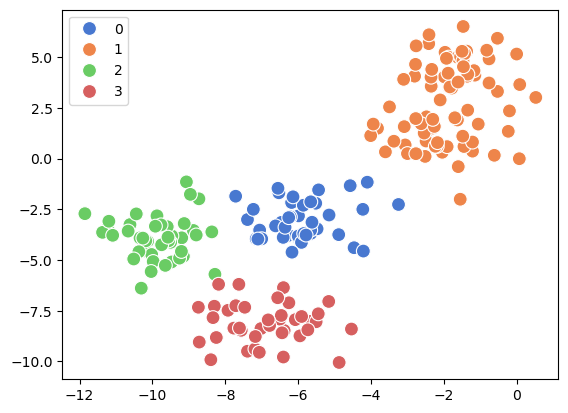

In [4]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4)
y_pred3 = km.fit_predict(X_prep)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_pred3, palette='muted', s=100);

# Внешние
Если известны истинные метки

## Rand Index

$$
RI = \frac{a+b}{C_2^{n_{samples}}}
$$

In [12]:
from itertools import combinations
def rand_index(labels_true, labels_pred):
    n = len(labels_true)
    a = 0
    b = 0

    for i, j in combinations(range(n), 2):
        same_true = labels_true[i] == labels_true[j]
        same_pred = labels_pred[i] == labels_pred[j]
        if same_true and same_pred:
            a += 1
        elif not same_true and not same_pred:
            b += 1
            
    total_pairs = n * (n - 1) // 2
    return (a + b) / total_pairs

rand_index(y, y_AP)

0.9270854271356784

In [6]:
from sklearn.metrics import rand_score
rand_score(y, y_AP)

0.9270854271356784

## Adjusted Rand Index

In [7]:
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(y, y_AP)

0.7392830281015494

# matual info | ami

In [31]:
from sklearn.metrics import mutual_info_score
mutual_info_score(y, y_pred)

1.4932024605009817

In [32]:
from sklearn.metrics import normalized_mutual_info_score
normalized_mutual_info_score(y, y_pred)

0.8236986142884413

In [45]:
from sklearn.metrics import adjusted_mutual_info_score
adjusted_mutual_info_score(y, y_pred)

0.8161019214758406

# homogeneity, completeness, v_measure

In [34]:
from sklearn.metrics import homogeneity_score
homogeneity_score(y, y_pred)

0.927778853079629

In [35]:
from sklearn.metrics import completeness_score
completeness_score(y, y_pred)

0.740614839437287

In [37]:
from sklearn.metrics import v_measure_score
v_measure_score(y, y_pred)

0.8236986142884413

In [38]:
from sklearn.metrics import homogeneity_completeness_v_measure
homogeneity_completeness_v_measure(y, y_pred)

(0.927778853079629, 0.740614839437287, 0.8236986142884413)

# fowlkes mallows score

In [40]:
from sklearn.metrics import fowlkes_mallows_score
fowlkes_mallows_score(y, y_pred)

0.7936730837648884

------

# Silhouette Coefficient

In [41]:
from sklearn.metrics import silhouette_score
silhouette_score(X, y_pred)

0.4276761603548577

# Calinski-Harabasz Index 

In [43]:
from sklearn.metrics import calinski_harabasz_score
calinski_harabasz_score(X, y_pred)

586.6661384081094

# Davies-Bouldin Index

In [44]:
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(X, y_pred)

0.9590150379480966